# Klasifikasi Persepsi Suhu Udara dengan KNN

Tujuan: Memprediksi persepsi Marry terhadap suhu udara (Panas/Dingin) berdasarkan:
- **Temperature** (Temperatur dalam °C)
- **Wind Speed** (Kecepatan angin dalam km/h)

Pertanyaan:
1. Bagaimana persepsi Marry saat temperatur 16°C dan kecepatan angin 3 km/h?
2. Tentukan nilai K yang tepat berdasarkan akurasi terbaik

## 1. Import Library dan Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv('../data/weather_classification_data.csv')

print("Dimensi dataset:", df.shape)
print("\n5 Data Pertama:")
df.head()

Dimensi dataset: (13200, 11)

5 Data Pertama:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## 2. Eksplorasi Data

In [ ]:
print("Informasi Dataset:")
print(df.info())
print("\n" + "="*50)
print("\nStatistik Deskriptif:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB
None


Statistik Deskriptif:


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing Values:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Total missing values: 0


## 3. Membuat Klasifikasi Persepsi (Panas/Dingin)

Kita akan membuat kolom target berdasarkan temperatur:
- **Dingin**: Temperature < 20°C
- **Panas**: Temperature >= 20°C

In [ ]:
# Membuat kolom persepsi berdasarkan temperatur
# Threshold: < 20°C = Dingin, >= 20°C = Panas
df['Persepsi_Marry'] = df['Temperature'].apply(lambda x: 'Dingin' if x < 20 else 'Panas')

print("Distribusi Persepsi Marry:")
print(df['Persepsi_Marry'].value_counts())
print("\nPersentase:")
print(df['Persepsi_Marry'].value_counts(normalize=True) * 100)

Distribusi Persepsi Marry:
Persepsi_Marry
Panas     7199
Dingin    6001
Name: count, dtype: int64

Persentase:
Persepsi_Marry
Panas     54.537879
Dingin    45.462121
Name: proportion, dtype: float64


C:\Users\nuril\AppData\Local\Temp\ipykernel_18228\1413667029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Persepsi_Marry', y='Temperature', ax=axes[0], palette='coolwarm')
C:\Users\nuril\AppData\Local\Temp\ipykernel_18228\1413667029.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Persepsi_Marry', y='Wind Speed', ax=axes[1], palette='coolwarm')


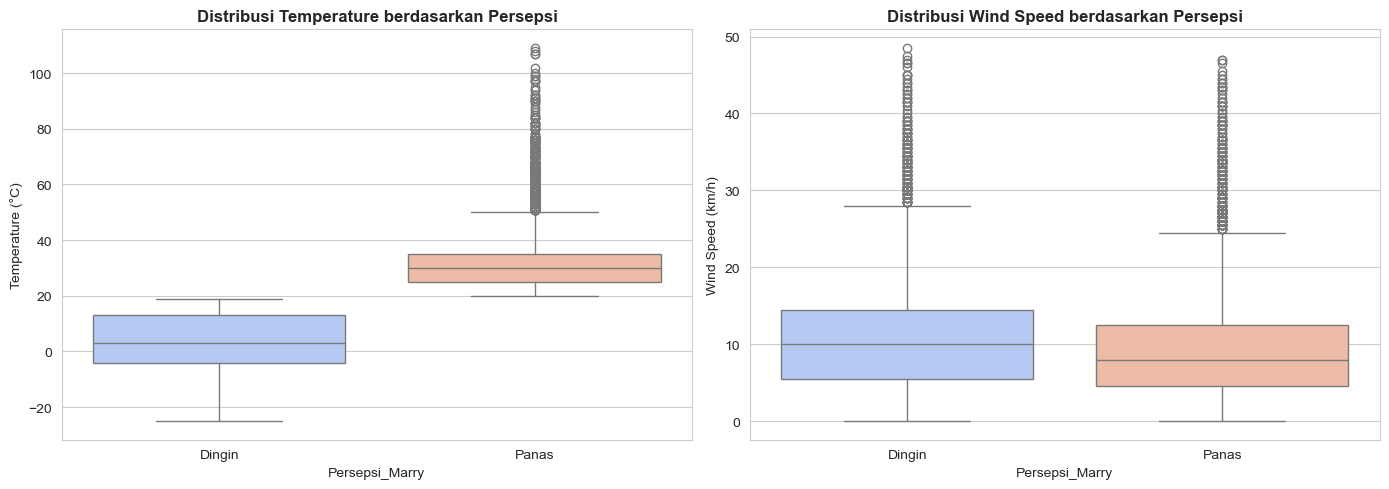

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Persepsi_Marry', y='Temperature', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribusi Temperature berdasarkan Persepsi', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)')

sns.boxplot(data=df, x='Persepsi_Marry', y='Wind Speed', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribusi Wind Speed berdasarkan Persepsi', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Wind Speed (km/h)')

plt.tight_layout()
plt.show()

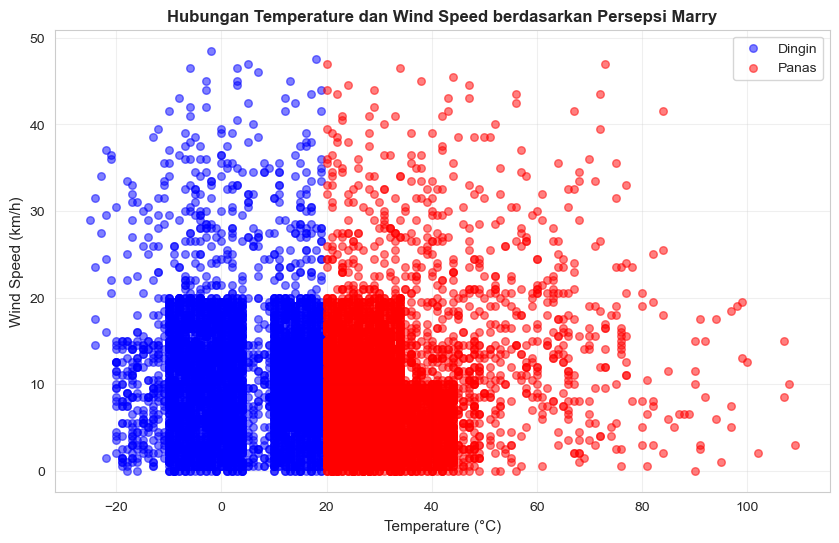

In [ ]:
plt.figure(figsize=(10, 6))
colors = {'Dingin': 'blue', 'Panas': 'red'}
for persepsi in df['Persepsi_Marry'].unique():
    subset = df[df['Persepsi_Marry'] == persepsi]
    plt.scatter(subset['Temperature'], subset['Wind Speed'], 
                c=colors[persepsi], label=persepsi, alpha=0.5, s=30)

plt.xlabel('Temperature (°C)', fontsize=11)
plt.ylabel('Wind Speed (km/h)', fontsize=11)
plt.title('Hubungan Temperature dan Wind Speed berdasarkan Persepsi Marry', 
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Persiapan Data untuk Model KNN

In [21]:
X = df[['Temperature', 'Wind Speed']]
y = df['Persepsi_Marry']
print("Fitur (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())
print("\nShape X:", X.shape)
print("Shape y:", y.shape)

Fitur (X):
   Temperature  Wind Speed
0         14.0         9.5
1         39.0         8.5
2         30.0         7.0
3         38.0         1.5
4         27.0        17.0

Target (y):
0    Dingin
1     Panas
2     Panas
3     Panas
4     Panas
Name: Persepsi_Marry, dtype: object

Shape X: (13200, 2)
Shape y: (13200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Training:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("\nData Testing:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print("\nDistribusi kelas di data training:")
print(y_train.value_counts())

Data Training:
X_train: (10560, 2)
y_train: (10560,)

Data Testing:
X_test: (2640, 2)
y_test: (2640,)

Distribusi kelas di data training:
Persepsi_Marry
Panas     5759
Dingin    4801
Name: count, dtype: int64


## 5. Normalisasi Data

KNN sangat sensitif terhadap skala fitur, sehingga perlu dilakukan normalisasi menggunakan StandardScaler.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data sebelum normalisasi:")
print(X_train.head())
print("\nData setelah normalisasi:")
print(pd.DataFrame(X_train_scaled, columns=['Temperature', 'Wind Speed']).head())
print("\nMean setelah scaling:", X_train_scaled.mean(axis=0))
print("Std setelah scaling:", X_train_scaled.std(axis=0))

Data sebelum normalisasi:
       Temperature  Wind Speed
1163          27.0        18.0
2081          16.0        11.0
7070          31.0         3.5
10792          3.0         6.0
9031          33.0         7.0

Data setelah normalisasi:
   Temperature  Wind Speed
0     0.451307    1.195827
1    -0.180785    0.180918
2     0.681159   -0.906484
3    -0.927804   -0.544017
4     0.796085   -0.399030

Mean setelah scaling: [9.11728605e-17 4.03717464e-17]
Std setelah scaling: [1. 1.]


## 6. Mencari Nilai K Terbaik

Kita akan mencoba berbagai nilai K (1-20) dan menggunakan cross-validation untuk menentukan K dengan akurasi terbaik.

In [ ]:
k_range = range(1, 21)
k_scores_train = []
k_scores_test = []
k_scores_cv = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_scaled, y_train)
    train_score = knn.score(X_train_scaled, y_train)
    k_scores_train.append(train_score)
    
    test_score = knn.score(X_test_scaled, y_test)
    k_scores_test.append(test_score)
    
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores_cv.append(cv_scores.mean())

results_df = pd.DataFrame({
    'K': list(k_range),
    'Train_Accuracy': k_scores_train,
    'Test_Accuracy': k_scores_test,
    'CV_Accuracy': k_scores_cv
})

print("Hasil Akurasi untuk berbagai nilai K:")
print(results_df.to_string(index=False))

Hasil Akurasi untuk berbagai nilai K:
 K  Train_Accuracy  Test_Accuracy  CV_Accuracy
 1        1.000000       0.998864     0.998769
 2        0.999905       0.997727     0.998011
 3        0.999811       0.998864     0.998106
 4        0.999242       0.997348     0.996875
 5        0.999242       0.998485     0.997727
 6        0.999148       0.997727     0.996686
 7        0.999053       0.998485     0.996970
 8        0.998864       0.998485     0.995833
 9        0.998958       0.998485     0.996023
10        0.999337       0.998485     0.996023
11        0.999053       0.998864     0.995739
12        0.997348       0.995833     0.995644
13        0.998390       0.997727     0.995644
14        0.997917       0.996970     0.996117
15        0.996970       0.996591     0.996023
16        0.997443       0.997727     0.996117
17        0.996686       0.996970     0.995928
18        0.996686       0.996970     0.996970
19        0.996780       0.996970     0.996780
20        0.997443    

In [ ]:
best_k_test = results_df.loc[results_df['Test_Accuracy'].idxmax(), 'K']
best_accuracy_test = results_df['Test_Accuracy'].max()

best_k_cv = results_df.loc[results_df['CV_Accuracy'].idxmax(), 'K']
best_accuracy_cv = results_df['CV_Accuracy'].max()

print("\n" + "="*60)
print("NILAI K TERBAIK:")
print("="*60)
print(f"Berdasarkan Test Accuracy: K = {int(best_k_test)} dengan akurasi {best_accuracy_test:.4f} ({best_accuracy_test*100:.2f}%)")
print(f"Berdasarkan CV Accuracy: K = {int(best_k_cv)} dengan akurasi {best_accuracy_cv:.4f} ({best_accuracy_cv*100:.2f}%)")
print("="*60)


NILAI K TERBAIK:
Berdasarkan Test Accuracy: K = 1 dengan akurasi 0.9989 (99.89%)
Berdasarkan CV Accuracy: K = 1 dengan akurasi 0.9988 (99.88%)


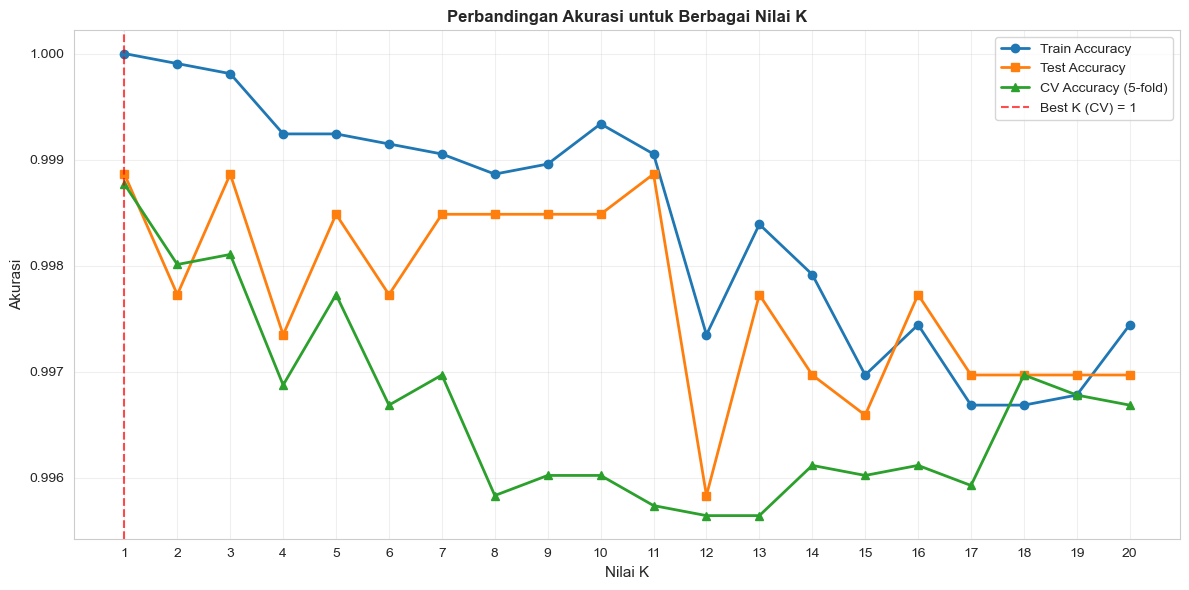

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(k_range, k_scores_train, marker='o', label='Train Accuracy', linewidth=2)
plt.plot(k_range, k_scores_test, marker='s', label='Test Accuracy', linewidth=2)
plt.plot(k_range, k_scores_cv, marker='^', label='CV Accuracy (5-fold)', linewidth=2)

plt.xlabel('Nilai K', fontsize=11)
plt.ylabel('Akurasi', fontsize=11)
plt.title('Perbandingan Akurasi untuk Berbagai Nilai K', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.axvline(x=best_k_cv, color='red', linestyle='--', alpha=0.7, label=f'Best K (CV) = {int(best_k_cv)}')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Training Model dengan K Terbaik

In [ ]:

best_k = int(best_k_cv)

# Training model final
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Prediksi pada data testing
y_pred = knn_final.predict(X_test_scaled)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model KNN dengan K = {best_k}")
print("="*60)
print(f"Akurasi pada data testing: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model KNN dengan K = 1
Akurasi pada data testing: 0.9989 (99.89%)

Classification Report:
              precision    recall  f1-score   support

      Dingin       1.00      1.00      1.00      1200
       Panas       1.00      1.00      1.00      1440

    accuracy                           1.00      2640
   macro avg       1.00      1.00      1.00      2640
weighted avg       1.00      1.00      1.00      2640



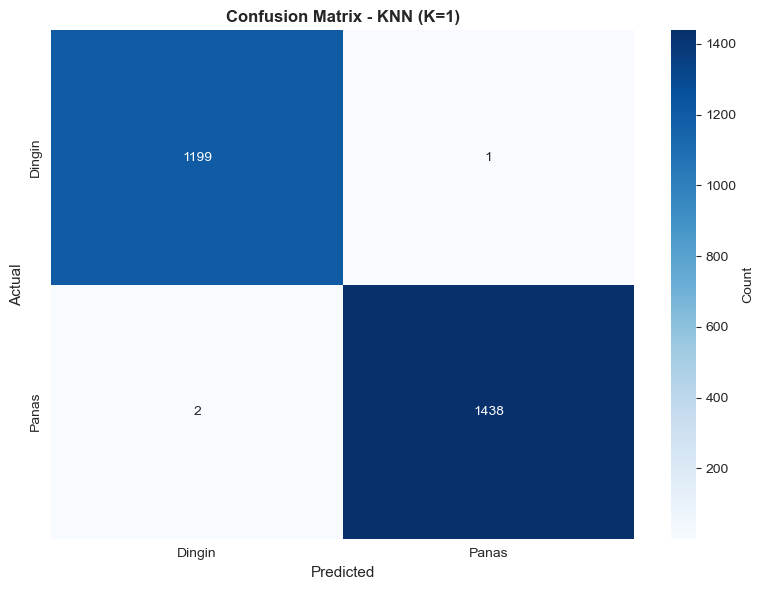


Confusion Matrix:
True Dingin: 1199
False Panas (seharusnya Dingin): 1
False Dingin (seharusnya Panas): 2
True Panas: 1438


In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dingin', 'Panas'], 
            yticklabels=['Dingin', 'Panas'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - KNN (K={best_k})', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(f"True Dingin: {cm[0,0]}")
print(f"False Panas (seharusnya Dingin): {cm[0,1]}")
print(f"False Dingin (seharusnya Panas): {cm[1,0]}")
print(f"True Panas: {cm[1,1]}")

## 8. Prediksi Persepsi Marry untuk Kondisi Spesifik

**Pertanyaan**: Bagaimana persepsi Marry saat:
- Temperature: 16°C
- Wind Speed: 3 km/h

In [16]:
# Data baru untuk prediksi
new_data = pd.DataFrame({
    'Temperature': [16],
    'Wind Speed': [3]
})

print("Data yang akan diprediksi:")
print(new_data)
print("\n" + "="*60)

Data yang akan diprediksi:
   Temperature  Wind Speed
0           16           3



In [17]:
# Normalisasi data baru menggunakan scaler yang sama
new_data_scaled = scaler.transform(new_data)

# Prediksi menggunakan model KNN terbaik
prediction = knn_final.predict(new_data_scaled)
prediction_proba = knn_final.predict_proba(new_data_scaled)

print("HASIL PREDIKSI:")
print("="*60)
print(f"Temperature: 16°C")
print(f"Wind Speed: 3 km/h")
print(f"\nPersepsi Marry: {prediction[0]}")
print(f"\nProbabilitas:")
print(f"  - Dingin: {prediction_proba[0][0]:.4f} ({prediction_proba[0][0]*100:.2f}%)")
print(f"  - Panas: {prediction_proba[0][1]:.4f} ({prediction_proba[0][1]*100:.2f}%)")
print("="*60)

HASIL PREDIKSI:
Temperature: 16°C
Wind Speed: 3 km/h

Persepsi Marry: Dingin

Probabilitas:
  - Dingin: 1.0000 (100.00%)
  - Panas: 0.0000 (0.00%)


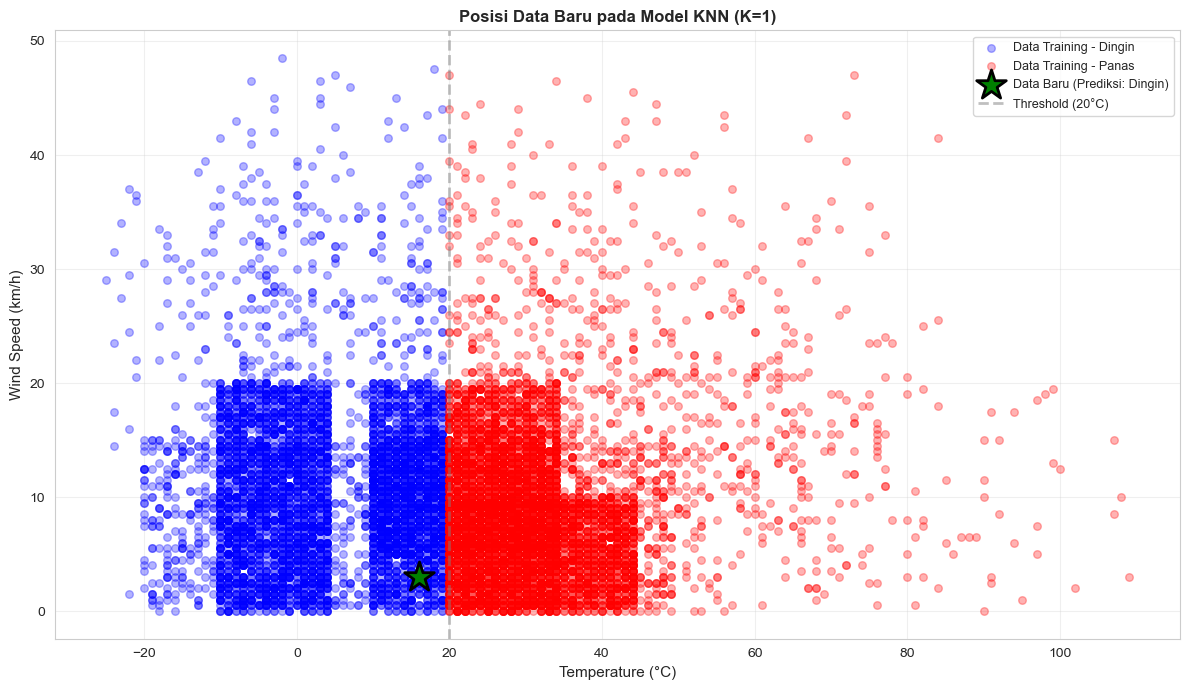

In [18]:
# Visualisasi: Posisi data baru pada scatter plot
plt.figure(figsize=(12, 7))

# Plot data training
colors_map = {'Dingin': 'blue', 'Panas': 'red'}
for persepsi in df['Persepsi_Marry'].unique():
    subset = df[df['Persepsi_Marry'] == persepsi]
    plt.scatter(subset['Temperature'], subset['Wind Speed'], 
                c=colors_map[persepsi], label=f'Data Training - {persepsi}', 
                alpha=0.3, s=30)

# Plot data baru yang diprediksi
plt.scatter(16, 3, c='green', marker='*', s=500, 
            edgecolors='black', linewidth=2,
            label=f'Data Baru (Prediksi: {prediction[0]})', zorder=5)

# Tambahkan threshold line
plt.axvline(x=20, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Threshold (20°C)')

plt.xlabel('Temperature (°C)', fontsize=11)
plt.ylabel('Wind Speed (km/h)', fontsize=11)
plt.title(f'Posisi Data Baru pada Model KNN (K={best_k})', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Melihat tetangga terdekat dari data baru
distances, indices = knn_final.kneighbors(new_data_scaled)

print(f"\n{best_k} Tetangga Terdekat dari Data Baru:")
print("="*60)
neighbors_df = X_train.iloc[indices[0]].copy()
neighbors_df['Persepsi'] = y_train.iloc[indices[0]].values
neighbors_df['Jarak'] = distances[0]
neighbors_df['No'] = range(1, best_k + 1)
neighbors_df = neighbors_df[['No', 'Temperature', 'Wind Speed', 'Persepsi', 'Jarak']]

print(neighbors_df.to_string(index=False))
print("\nDistribusi Persepsi pada tetangga terdekat:")
print(neighbors_df['Persepsi'].value_counts())


1 Tetangga Terdekat dari Data Baru:
 No  Temperature  Wind Speed Persepsi  Jarak
  1         16.0         3.0   Dingin    0.0

Distribusi Persepsi pada tetangga terdekat:
Persepsi
Dingin    1
Name: count, dtype: int64


## 9. Kesimpulan

### Jawaban Pertanyaan:

**1. Persepsi Marry saat Temperature 16°C dan Wind Speed 3 km/h:**
- Akan ditampilkan setelah menjalankan sel prediksi di atas

**2. Nilai K yang tepat:**
- Akan ditampilkan berdasarkan hasil cross-validation di atas
- K dipilih berdasarkan akurasi tertinggi dengan mempertimbangkan overfitting dan underfitting

### Penjelasan Model:
- **Algoritma**: K-Nearest Neighbors (KNN)
- **Fitur**: Temperature (°C) dan Wind Speed (km/h)
- **Target**: Persepsi Marry (Panas/Dingin)
- **Threshold**: Temperature < 20°C = Dingin, >= 20°C = Panas
- **Preprocessing**: StandardScaler untuk normalisasi fitur
- **Evaluasi**: Cross-validation 5-fold untuk memilih K terbaik